In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../MERS/')


In [2]:

import scipy.optimize
import scipy.interpolate

# Ensure this is at the very top of your notebook
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable problematic Metal plugin
tf.keras.utils.disable_interactive_logging() # turn off annoying progress indicator

In [3]:
import VeryAccurateEmulator as VAE
emulator = VAE.emulator.DirectEmulator()
emulator.load_model()  # load pretrained emulator. Use the model_path kwarg to load other models.
# Add after model loading
emulator.emulator.compile(
    optimizer='adam',  # Match your original optimizer
    loss='mse',        # Match your original loss function
    metrics=['mae']    # Add your original metrics
)
emulator.emulator.summary()

/opt/homebrew/Caskroom/miniconda/base/envs/astro_env/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [4]:
params = emulator.par_labels
params

['fstar', 'Vc', 'fx', 'tau', 'alpha', 'nu_min', 'Rmfp']

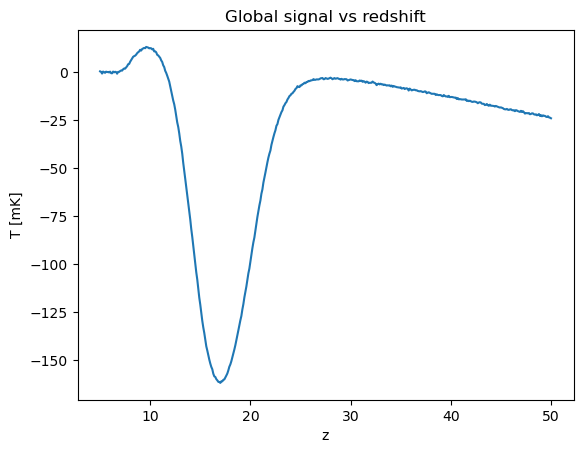

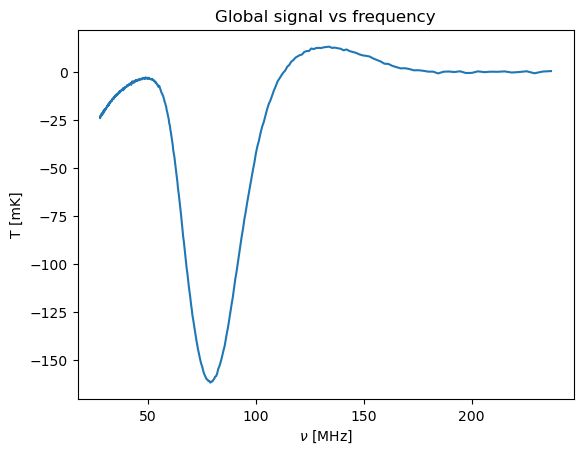

In [5]:


#p0 = [0.0003, 4.2, 0, 0.055, 1.0, 0.1, 10]  # in the order given in the above cell
p0 = [10.**-0.8, 10.**1.4803, 10.**-0.1190, 0.07, 1.25, 0.85, 29.6]  # in the order given in the above cell

# alternatively, params can be a (N, 7)-numpy array, where N is the number of different cases you want to emulate at once.
# In that case, the output is a (N, 451)-numpy array. 
# For example, if you have a csv file with 500 cases organized in a 500x7-table, just do 
# params = np.loadtxt(<filepath>)

global_signal = emulator.predict(p0)  # emulate the global signal

redshifts = emulator.redshifts  # an array of length 451 with redshifts 5-50:0.1
plt.figure()
plt.plot(redshifts, global_signal)
plt.title('Global signal vs redshift')
plt.xlabel('z')
plt.ylabel('T [mK]')
plt.show()

frequencies = emulator.frequencies  # an array of length 451 with equivalent frequencies
plt.figure()
plt.plot(frequencies, global_signal)
plt.title('Global signal vs frequency')
plt.xlabel(r'$\nu$ [MHz]')
plt.ylabel('T [mK]')
plt.show()

In [6]:
# Parameters to vary
Nmodels = 80
ranges = {
    'fstar':    (1e-4, 0.5),
    'Vc':       (4.2, 100.),
    'fx':       (1e-5, 1000.),
    'nu_min':   (0.1, 3.0)
}

# Randomly sample free parameters (keep others fixed)
vals = []
for i, param in enumerate(params):
    pp = p0[i] * np.ones(Nmodels)
    if param in ranges.keys():
        if param == 'nu_min':
            pp = np.random.uniform(low=ranges[param][0], 
                                   high=ranges[param][1], 
                                   size=Nmodels)
        else:
            pp = 10.**np.random.uniform(low=np.log10(ranges[param][0]), 
                                        high=np.log10(ranges[param][1]), 
                                        size=Nmodels)
            
    vals.append(pp)

vals = np.array(vals).T
print(vals.shape)

gs = emulator.predict(vals)

# plt.subplot(211)
# plt.plot(frequencies, gs.T, color='k', alpha=0.2)
# plt.xlabel("Freqs. [MHz]")

# plt.subplot(212)
# plt.plot(frequencies, gs.T, color='k', alpha=0.2)
# plt.xlabel("Freqs. [MHz]")

# plt.gcf().set_size_inches((16., 9.))

(80, 7)


(80, 7)


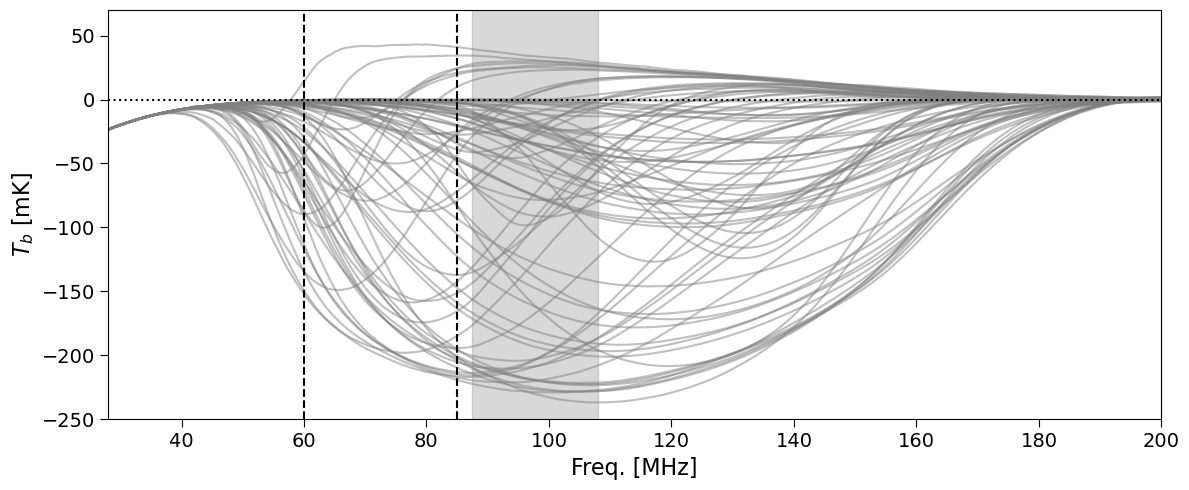

In [ ]:
from scipy.signal import savgol_filter

freqs_50_200 = np.linspace(50., 200., 101) # MHz

for i in range(gs.shape[0]):

    # Smooth the global signal
    smooth_gs = savgol_filter(gs[i], window_length=16, polyorder=3)
    
    # Interpolate onto our frequency channels
    interp = scipy.interpolate.interp1d(frequencies, smooth_gs, kind='cubic')
    gs_interp_50_200 = interp(freqs_50_200)
    
    # Plot full 21cm emulator prediction, and interpolated values within our band
    y = vals[i,1] - np.min(vals[:,1])
    y /= np.max(np.log10(vals[:,1])) - np.min(np.log10(vals[:,1]))
    col = plt.cm.Spectral(y)
    #print(y)
    plt.plot(frequencies, smooth_gs, color='grey', alpha=0.5)
    # plt.plot(freqs, gs_interp, color='r', alpha=0.5)

    #if i == 24:
    #    plt.plot(freqs, gs_interp, color='c', lw=4.)

    # Apply FG filter to interpolated theory function
    #_coeffs = gs_interp @ fg_operator
    #fg_part = (_coeffs @ fg_operator.T).real
    #plt.plot(freqs, fg_part, 'b--', alpha=0.7)
    #plt.plot(freqs, gs_interp - fg_part, 'g-', alpha=0.7)
print(vals.shape)
plt.xlim((28., 200.))
#plt.xlim((50., 90.))
plt.ylim((-250., 70.))

plt.axvline(60., ls='dashed', color='k')
plt.axvline(85., ls='dashed', color='k')
plt.axhline(0., ls='dotted', color='k')

plt.fill_betweenx(np.array([-350., 150.]), 87.5, 108., color='grey', alpha=0.3)

plt.xlabel("Freq. [MHz]", fontsize=16)
plt.ylabel("$T_b$ [mK]", fontsize=16)
plt.tick_params(which='both', size=6., labelsize=14)
plt.gcf().set_size_inches((12., 5.))
#plt.gcf().set_size_inches((5., 5.))
plt.tight_layout()
plt.savefig("tb_theory.pdf")

## Construct the covariance matrix of global 21cm signal

In [7]:
from scipy.interpolate import interp1d

target_freqs=np.arange(55.0, 85.0+0.5, 0.5) # MHz
gs_interpolated = np.zeros((len(gs),len(target_freqs)))
for i in range(len(gs)):
    data = gs[i]
    gs_interpolated[i, :] = interp1d(frequencies, data, kind='cubic', fill_value='extrapolate')(target_freqs)

cov_gs = gs_interpolated.T @ gs_interpolated
# Save the covariance matrix
np.save('signal_cov_55_85.npy', cov_gs)

target_freqs=np.linspace(50., 200., 101) # MHz
gs_interpolated = np.zeros((len(gs),len(target_freqs)))
for i in range(len(gs)):
    data = gs[i]
    gs_interpolated[i, :] = interp1d(frequencies, data, kind='cubic', fill_value='extrapolate')(target_freqs)

cov_gs = gs_interpolated.T @ gs_interpolated
# Save the covariance matrix
np.save('signal_cov_50_200.npy', cov_gs)

In [8]:
interp = scipy.interpolate.interp1d(frequencies, global_signal, kind='cubic')
freqs_50_200 = np.linspace(50., 200., 101) # MHz
global_signal_instance_50_200 = interp(freqs_50_200)

freqs_55_85 = np.arange(55.0, 85.0+0.5, 0.5) # MHz
global_signal_instance_55_85 = interp(freqs_55_85)

np.save('global_signal_50_200.npy', global_signal_instance_50_200)
np.save('global_signal_55_85.npy', global_signal_instance_55_85)


In [9]:
cov_gs = gs_interpolated.T @ gs_interpolated
# Save the covariance matrix
np.save('signal_cov.npy', cov_gs)

In [23]:
# Ensure matrix is symmetric (should already be for covariance matrix)
assert np.allclose(cov_gs, cov_gs.T)

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_gs)

# Reverse order to get descending eigenvalues
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1].T

reconst_cov = 0
for i in range(len(eigenvalues)):
    # Ensure proper orientation: use eigenvector as column vector
    vec = eigenvectors[i].reshape(-1, 1) if eigenvectors.shape[0] == len(eigenvalues) else eigenvectors[:, i].reshape(-1, 1)
    reconst_cov += eigenvalues[i] * vec @ vec.T

np.allclose(cov_gs, reconst_cov, atol=1e-8)  # Adjust tolerance if needed


True

In [24]:
signal_variance_ratio=[]
total_variance=np.sum(eigenvalues)
signal_variance_ratio = np.cumsum(eigenvalues)/total_variance
signal_variance_ratio

array([0.88130738, 0.97055586, 0.98869648, 0.99654991, 0.99856407,
       0.99947374, 0.99977208, 0.99990296, 0.99995444, 0.99997732,
       0.99998569, 0.99999024, 0.99999236, 0.9999932 , 0.99999384,
       0.99999436, 0.99999483, 0.99999528, 0.99999567, 0.99999603,
       0.99999634, 0.99999662, 0.9999969 , 0.99999714, 0.99999736,
       0.99999757, 0.99999776, 0.99999794, 0.99999812, 0.99999827,
       0.99999842, 0.99999856, 0.99999869, 0.99999881, 0.99999891,
       0.99999901, 0.99999911, 0.9999992 , 0.99999928, 0.99999935,
       0.99999941, 0.99999947, 0.99999952, 0.99999957, 0.99999961,
       0.99999965, 0.99999969, 0.99999973, 0.99999976, 0.99999978,
       0.99999981, 0.99999983, 0.99999985, 0.99999987, 0.99999989,
       0.9999999 , 0.99999992, 0.99999993, 0.99999994, 0.99999995,
       0.99999996, 0.99999996, 0.99999997, 0.99999997, 0.99999998,
       0.99999998, 0.99999999, 0.99999999, 0.99999999, 0.99999999,
       0.99999999, 1.        , 1.        , 1.        , 1.     

## 2. Joint fg and 21cm fit

In [21]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_gs)

# Reverse order to get descending eigenvalues
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

signal_basis = eigenvectors[:, :3]

In [22]:
global_signal_intp = interp1d(frequencies, global_signal, kind='cubic', fill_value='extrapolate')(target_freqs)

In [23]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u
import healpy as hp

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 22:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 2

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
nside = 512  # HEALPix resolution
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(nside, vecs[0], vecs[1], vecs[2])

# === Example output ===
for time, lst, pix in zip(times[:5], lst_array[:5], pix_indices[:5]):
    print(f"UTC: {time.iso} | LST: {lst.to_string(unit=u.hour)} | HEALPix pixel: {pix}")


UTC: 2024-10-01 22:00:00.000 | LST: 22h35m15.91468459s | HEALPix pixel: 1691211
UTC: 2024-10-01 22:02:00.000 | LST: 22h37m16.24323363s | HEALPix pixel: 1697357
UTC: 2024-10-01 22:04:00.000 | LST: 22h39m16.57178268s | HEALPix pixel: 1699406
UTC: 2024-10-01 22:06:00.000 | LST: 22h41m16.90033172s | HEALPix pixel: 1705552
UTC: 2024-10-01 22:08:00.000 | LST: 22h43m17.22888076s | HEALPix pixel: 1707601


In [24]:
data_cube = CNN_PL_RHINO[pix_indices,:] + global_signal_intp[:]
spec_ind_tod = Mel_model.specidx_map[pix_indices]

In [25]:
# # eigenvalues should already be sorted in descending order
# explained_variance_ratio = eigenvalues / eigenvalues.sum()
# cumulative_variance = explained_variance_ratio.cumsum()
# # Find the number of modes that explain 90% of the variance
# thres_21 = 0.9
# num_21modes = (cumulative_variance < thres_21 ).sum() + 1  # +1 to include the first mode that passes 90%

# # Select the modes
# signal_basis = eigenvectors[:num_21modes]

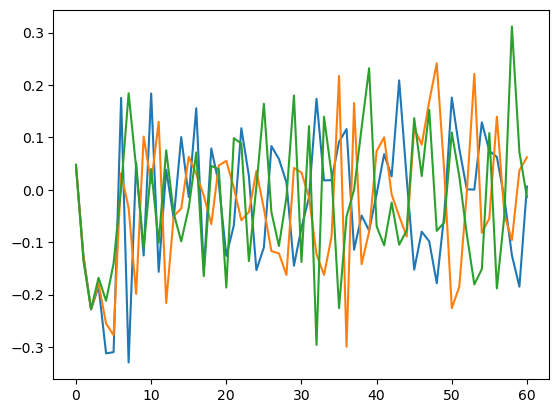

In [26]:
plt.plot(eigenvectors[:3].T, )

In [27]:
from SEDfitting import *

In [29]:
coeffs, losses, pivots = fit_fg_plus_21_cube(data_cube, signal_basis, spec_ind_tod, target_freqs, nu_ref=None, max_order=6, adaptive_pivot=True, BCSVD=BCSVD)

In [34]:
reconstructed_21cm = coeffs[:, -3:]@signal_basis.T

In [35]:
reconstructed_21cm.shape

(212, 61)

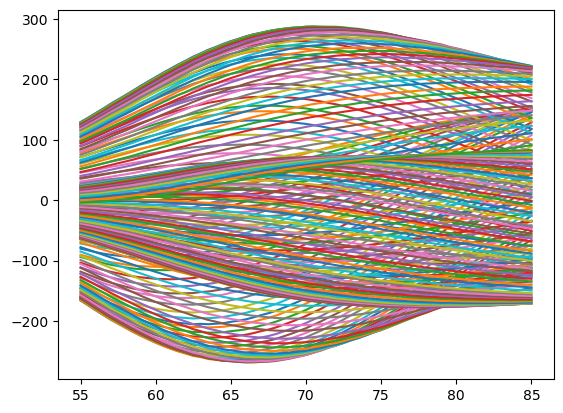

In [41]:
from cProfile import label


plt.plot(target_freqs, global_signal_intp, label='True')
plt.plot(target_freqs, reconstructed_21cm.T, label='Predicted')